# **SpaceX Falcon 9 First Stage Landing Prediction**


## Data Visualization and Feature Engineering


In this notebook, I'll continue my analysis to predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

This notebook focuses on exploratory data visualization and feature engineering to prepare for machine learning model development.


## Objectives

My goals in this notebook are to:

* Perform visual exploratory data analysis using `Pandas`, `Matplotlib`, and `Seaborn`
* Prepare the data through feature engineering for future machine learning applications


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%cd "/content/drive/Othercomputers/My MacBook Pro/portfolio/spacex-data-science-capstone"
file_prefix = %pwd

/content/drive/Othercomputers/My MacBook Pro/portfolio/spacex-data-science-capstone


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis


First, I'll read the SpaceX dataset I created earlier into a Pandas dataframe and examine its contents


In [4]:
df = pd.read_csv("data/dataset_part_2.csv")
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts) and `Payload` variables affect the launch outcome.

We can plot <code>FlightNumber</code> vs. <code>PayloadMass</code> and overlay the outcome of the launch.

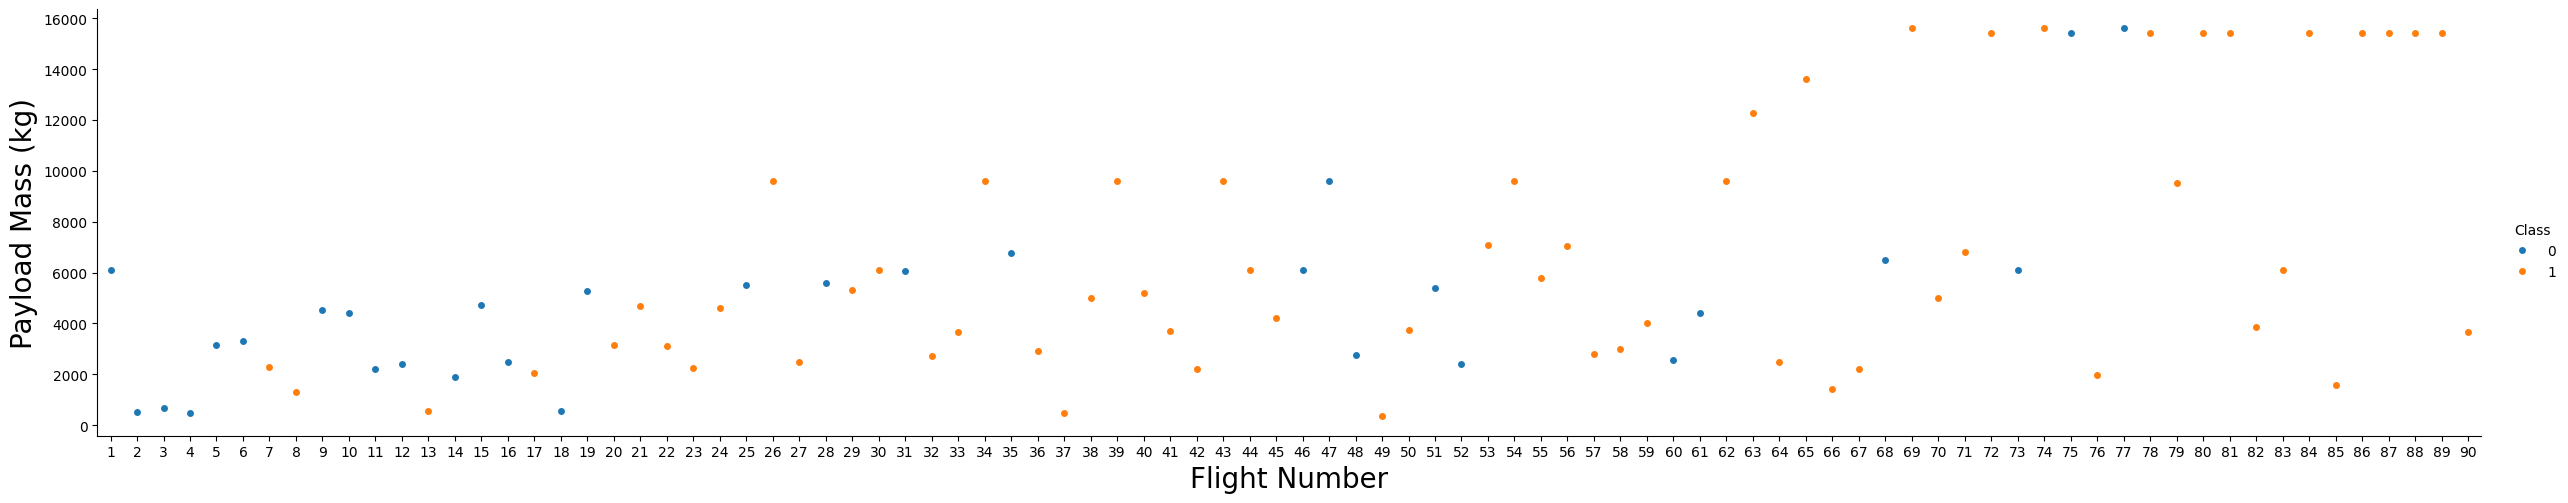

In [5]:
# Create a catplot to visualize Flight Number vs Payload Mass, colored by landing outcome
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.show()

We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.

We see that different launch sites have different success rates. `CCAFS LC-40` has a success rate of approximately 60%, while `KSC LC-39A` and `VAFB SLC 4E` have higher success rates of around 77%.


Next, I'll analyze each launch site in detail to visualize their specific launch records.


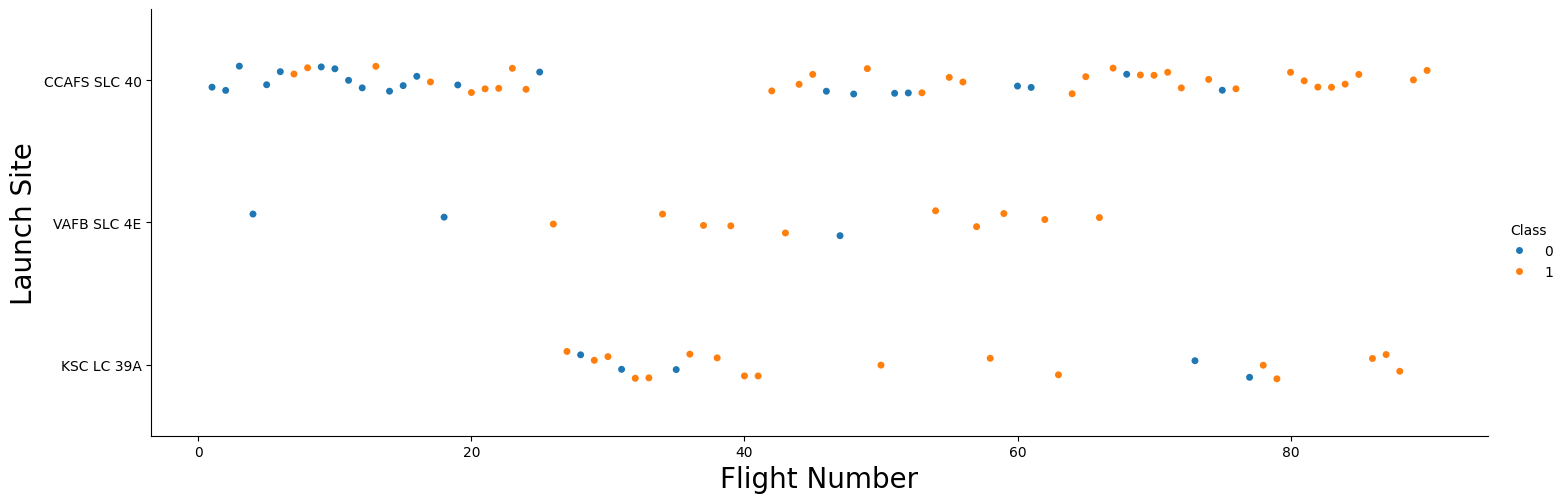

In [6]:
# Visualizing the relationship between Flight Number and Launch Site
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=3)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

Examining the Launch Site vs. Flight Number plots, we see first of all that the success rate increases with Flight Number -- that is, in time. Early flights exhibit a high failure rate, as one would expect. These flights also launch disproportionately from CCAFS SLC 40, suggesting the possibility of a temporal component to the differences in success rates between different launch sites generally.


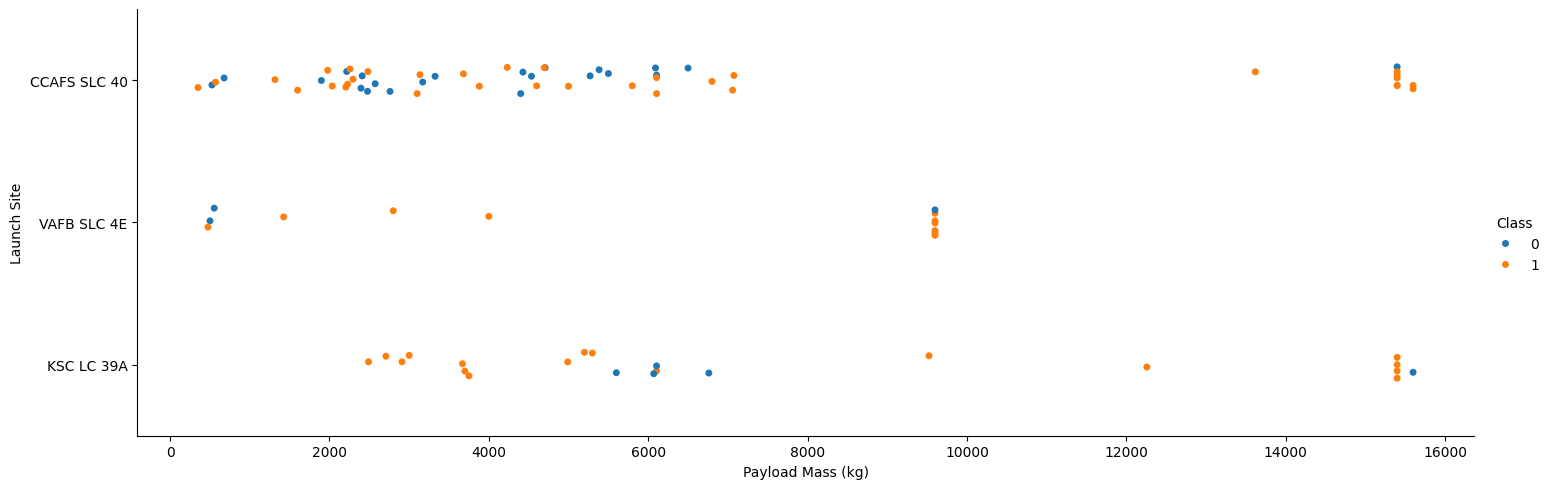

In [7]:
# Visualizing the relationship between Payload Mass and Launch Site
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=3)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.show()

We see that heavy payloads (greater than 10,000 kg) are not launched from VAFB-SLC. The other sites appear to accommodate a wider range of payload masses.


Next, I want to check if there's any relationship between success rate and orbit type.


<Axes: xlabel='Orbit'>

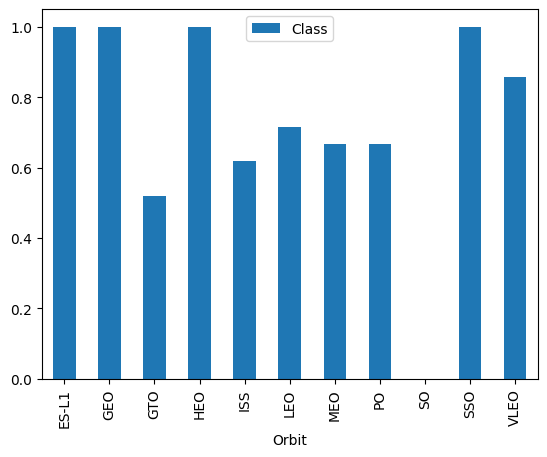

In [8]:
# Visualizing the success rate of each orbit type
df_success_rate = df.groupby("Orbit")["Class"].mean().reset_index()
df_success_rate.plot(kind="bar", x="Orbit", y="Class")

The bar chart indicates that there is a clear relationship between orbit type and success rate, with ES-L1, GEO, HEO, and SSO orbits exhibiting 100\% success rates.


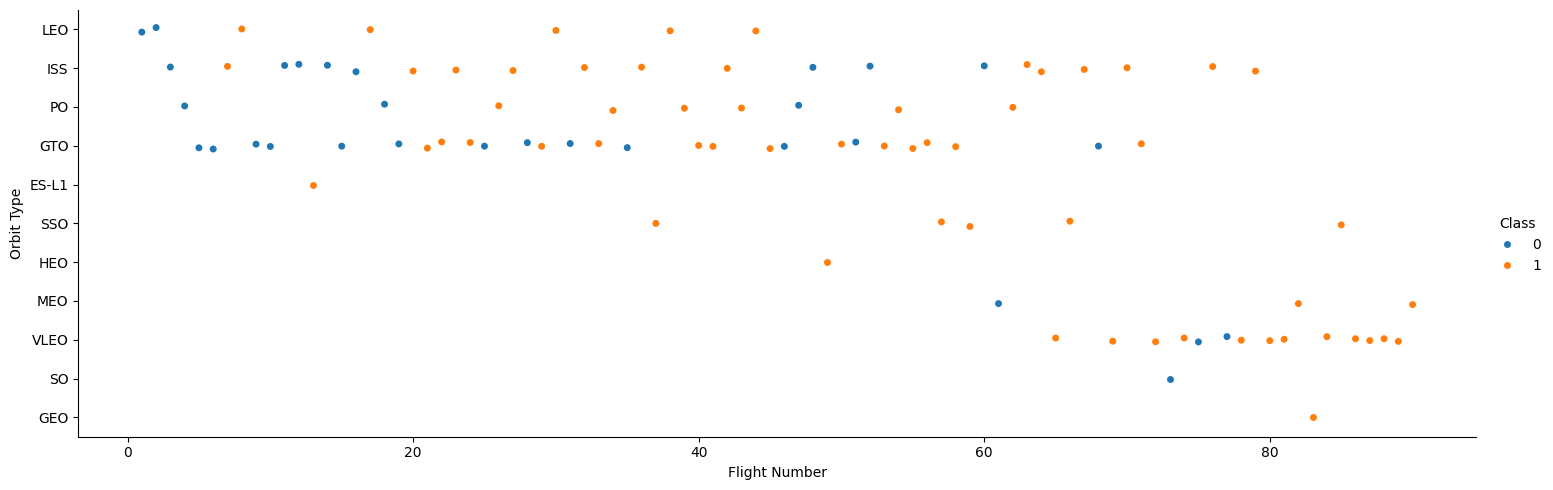

In [9]:
# Visualizing the relationship between Flight Number and Orbit type
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=3)
plt.xlabel("Flight Number")
plt.ylabel("Orbit Type")
plt.show()

From this plot, we see that most of the orbit types with 100\% success rates only have a single flight. The only exception is the SSO orbit, which is associated with five successful landings. We also see that there is a possible relationship between Flight Number and success in LEO orbit, but there is no indication of such a relationship in any of the other orbits.


Next, let's plot Orbit Type vs. Payload color coded by outcome:


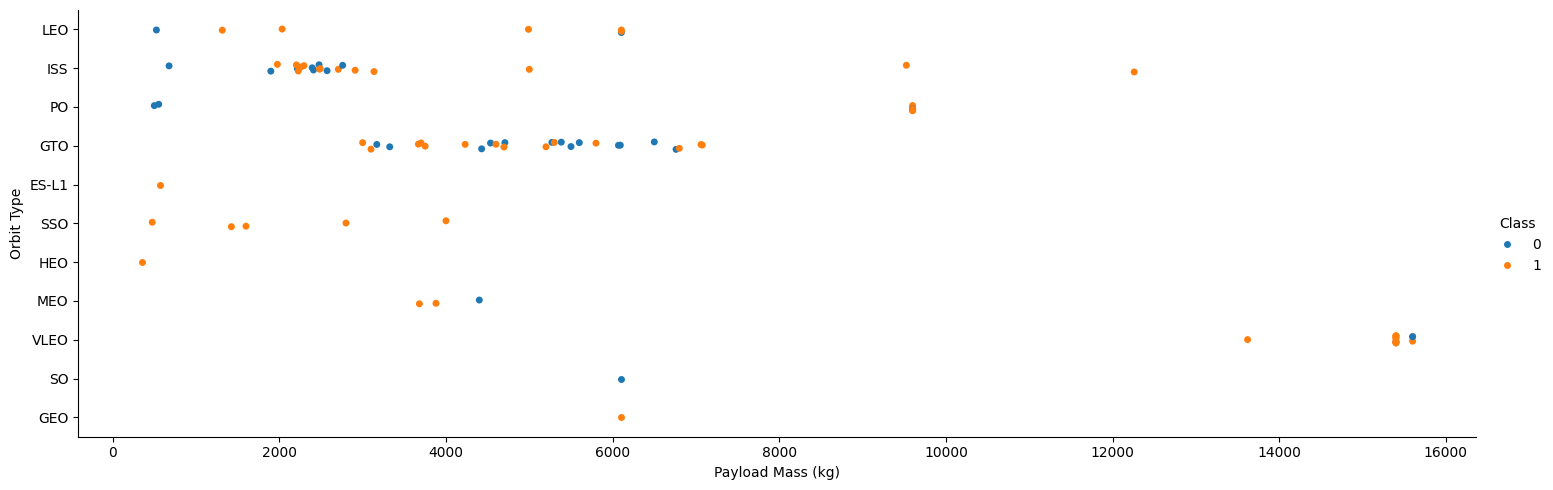

In [10]:
# Visualizing the relationship between Payload Mass and Orbit type
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=3)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit Type")
plt.show()

With the possible exception of ISS, there does not appear to be a strong relationship between payload mass and success for any Orbit Type. Interestingly, high-payload launches have a greater success rate overall (though there are fewer of them).

We also see that certain orbits (e.g., LEO, SSO, GTO) are only associated with smaller payloads, while VLEO is only associated with large payloads.

Now I'll examine the trend in success rate over time by plotting the average success rate by year.


First, I'll create a function to extract the year from the date field:


In [11]:
# A function to Extract years from the date
year = []
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Text(0, 0.5, 'Success Rate')

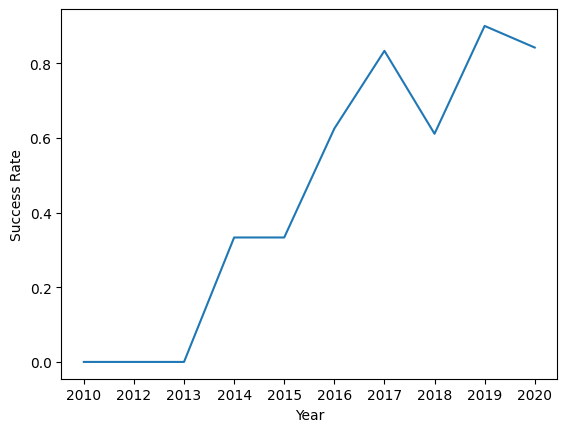

In [12]:
# Plot a line chart showing the success rate by year
success_rate = df.groupby("Date")["Class"].mean().reset_index()
plt.plot(success_rate["Date"], success_rate["Class"])
plt.xlabel("Year")
plt.ylabel("Success Rate")

The success rate has continuously improved from 2013 to 2019, with a dip in success rate in 2018 and 2020. This trend demonstrates SpaceX's improving technology and experience with first stage landings over time.


## Feature Engineering


Based on my exploratory analysis, I now have some preliminary insights about how various factors affect the success rate of first-stage landings. Now I'll select and prepare the features that will be used for building a predictive model in future notebooks.


In [13]:
# Select the features to be used in the prediction model
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


Many machine learning algorithms require numerical input, but several of my features are categorical. I'll use one-hot encoding to convert categorical variables like `Orbit`, `LaunchSite`, `LandingPad`, and `Serial` into numerical features.


In [17]:
# Apply one-hot encoding to categorical columns
features_one_hot = pd.get_dummies(features, columns=["Orbit", "LaunchSite", "LandingPad", "Serial"], dtype = int)
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,525.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,677.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,500.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,3170.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now that the `features_one_hot` dataframe contains only numerical values, we can convert all columns to the same data type (`float64`) for consistency.


In [18]:
# Convert all features to float64 type
features_one_hot = features_one_hot.astype("float64")

Finally, I'll export this processed dataset for use in my machine learning models in the next notebook.


In [ ]:
# Export the preprocessed features for later use
#features_one_hot.to_csv("data/dataset_part_3.csv", index=False)